# Velocity Autocorrelation and Green-Kubo Validation

The velocity autocorrelation function (VACF) is defined as

$$C_v(\tau) = \frac{\langle \mathbf{v}(t) \cdot \mathbf{v}(t+\tau) \rangle}{\langle |\mathbf{v}(t)|^2 \rangle}$$

so that $C_v(0) = 1$ by construction. The Green-Kubo relation connects the
VACF to the diffusion coefficient:

$$D = \frac{1}{3} \int_0^{\infty} \langle \mathbf{v}(t) \cdot \mathbf{v}(0) \rangle \, dt$$

Comparing $D_{\mathrm{GK}}$ from numerical integration of the VACF with
$D_{\mathrm{MSD}}$ from the power-law fit is an internal consistency check:
they should agree if the trajectory is long enough and the system is
ergodic. A negative dip in the VACF at short lag times is the spectral
signature of backscattering, the process by which a confined particle
collides with a cage wall and reverses direction. This dip is absent for
free diffusion and becomes deeper as confinement strengthens.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.io_utils import load_all_trajectories, DATA_DIR
from src.msd import compute_msd, fit_msd

trajs, meta = load_all_trajectories(DATA_DIR)

concs   = sorted({k[0] for k in trajs})
charges = sorted({k[1] for k in trajs})

# Four representative conditions spanning the regime space
study_conditions = [
    ('free',     0.00, 0.0),
    ('moderate', 0.15, 0.0),
    ('dense',    0.50, 0.0),
    ('hopping',  0.30, 6.0),
]

MAX_LAG = 300  # compute VACF up to this lag in frames

def compute_vacf(trajs_list, max_lag=MAX_LAG):
    """Compute normalised VACF averaged over a list of trajectory DataFrames."""
    vacf_runs = []
    for df in trajs_list:
        vx = df['vx'].to_numpy(dtype=float)
        vy = df['vy'].to_numpy(dtype=float)
        vz = df['vz'].to_numpy(dtype=float)
        n  = len(vx)
        var_v = vx.var() + vy.var() + vz.var()
        if var_v == 0:
            continue
        vacf_run = np.zeros(min(max_lag + 1, n))
        for lag in range(len(vacf_run)):
            vacf_run[lag] = (
                np.mean(vx[:n - lag] * vx[lag:]) +
                np.mean(vy[:n - lag] * vy[lag:]) +
                np.mean(vz[:n - lag] * vz[lag:])
            ) / var_v
        vacf_runs.append(vacf_run)
    return np.mean(vacf_runs, axis=0)

vacf_dict = {}
for label, conc, charge in study_conditions:
    dfs = [trajs[(conc, charge, r)] for r in range(8)
           if (conc, charge, r) in trajs]
    vacf_dict[label] = compute_vacf(dfs)
    print(f'{label} (phi={conc}, Z={charge}): VACF computed, {len(vacf_dict[label])} lags.')


Loading trajectories: 100%|████████████████| 160/160 [00:01<00:00, 127.63file/s]


Loaded 160 trajectories across 20 conditions.
free (phi=0.0, Z=0.0): VACF computed, 301 lags.
moderate (phi=0.15, Z=0.0): VACF computed, 301 lags.
dense (phi=0.5, Z=0.0): VACF computed, 301 lags.
hopping (phi=0.3, Z=6.0): VACF computed, 301 lags.


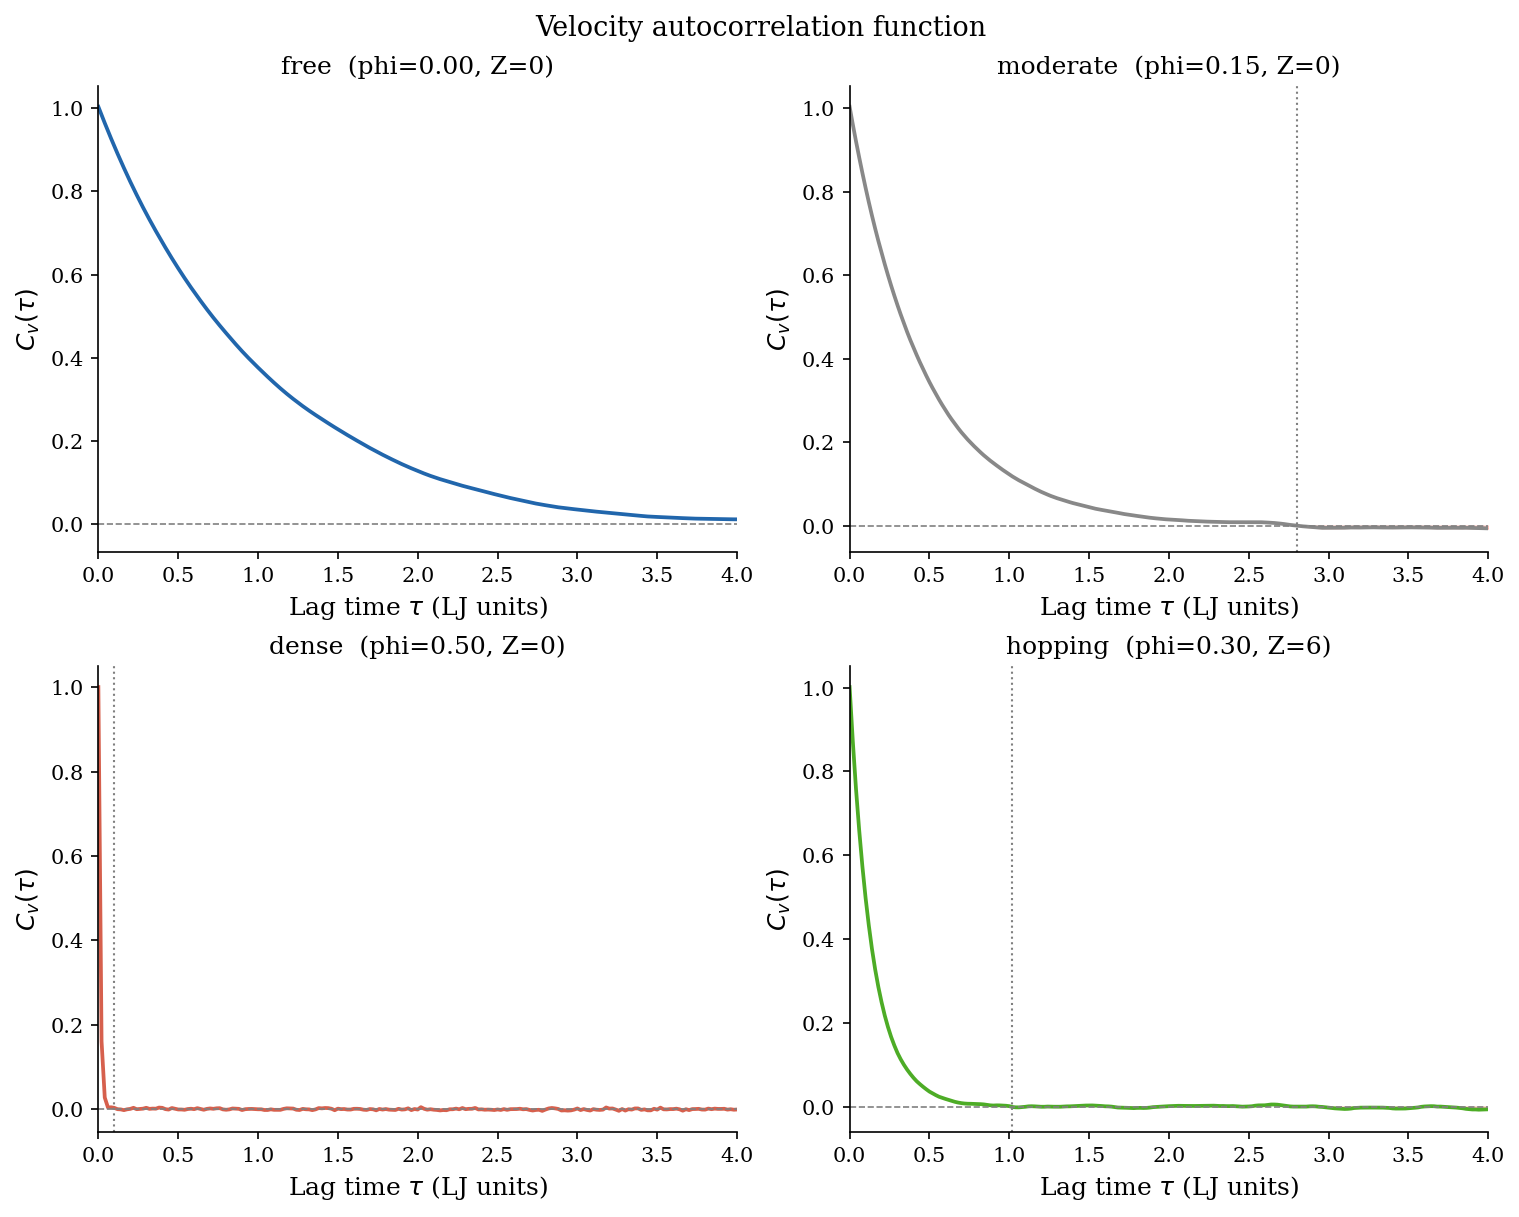

Saved: figures/04_vacf_comparison.png


In [4]:
# Figure 04a: VACF comparison (2x2 grid)
DT_SAVED = 0.02

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_flat = axes.flatten()
colours   = [REGIME_COLOURS['free'], REGIME_COLOURS['mixed'],
             REGIME_COLOURS['subdiff'], REGIME_COLOURS['hopping']]

for ax, (label, conc, charge), colour in zip(axes_flat, study_conditions, colours):
    vacf = vacf_dict[label]
    lag_arr = np.arange(len(vacf)) * DT_SAVED

    # Find zero crossing
    crossings = np.where(np.diff(np.sign(vacf)))[0]
    zero_lag  = crossings[0] * DT_SAVED if len(crossings) > 0 else None

    ax.plot(lag_arr, vacf, color=colour, lw=1.8, label=label)
    ax.axhline(0, color='grey', ls='--', lw=0.8)

    # Shade negative region
    ax.fill_between(lag_arr, vacf, 0,
                    where=(vacf < 0), color='salmon', alpha=0.35)

    if zero_lag is not None:
        ax.axvline(zero_lag, color='grey', ls=':', lw=1.0)

    # Annotate backscattering if VACF goes negative
    if vacf.min() < -0.02:
        neg_idx = np.argmin(vacf)
        ax.annotate('backscattering',
                    xy=(lag_arr[neg_idx], vacf[neg_idx]),
                    xytext=(lag_arr[neg_idx] + 0.5, vacf[neg_idx] - 0.06),
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))

    ax.set_title(f'{label}  (phi={conc:.2f}, Z={charge:.0f})')
    ax.set_xlabel(r'Lag time $\tau$ (LJ units)')
    ax.set_ylabel(r'$C_v(\tau)$')
    ax.set_xlim(0, min(len(vacf) * DT_SAVED, 4.0))

plt.suptitle('Velocity autocorrelation function', fontsize=13)
plt.savefig(f'{FIG_DIR}/04_vacf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/04_vacf_comparison.png")


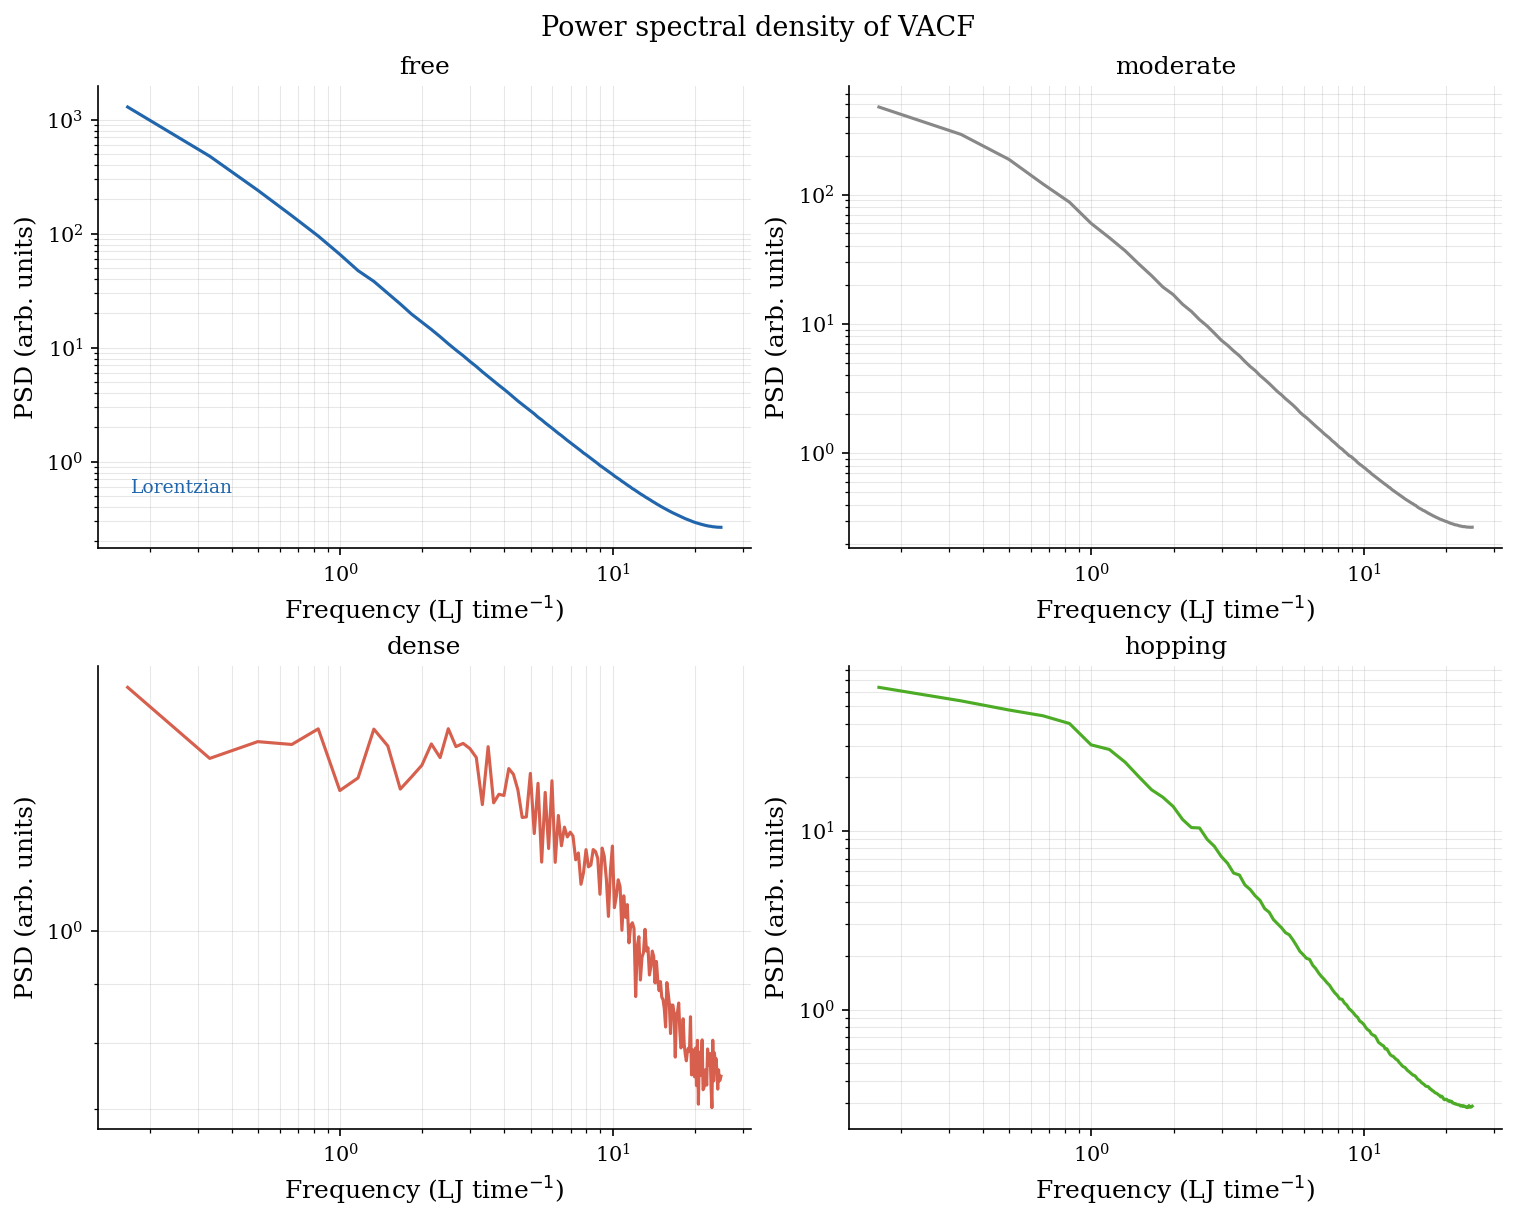

Saved: figures/04_power_spectrum.png


In [5]:
# Figure 04b: Power spectral density of VACF
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_flat = axes.flatten()

for ax, (label, conc, charge), colour in zip(axes_flat, study_conditions, colours):
    vacf = vacf_dict[label]
    n    = len(vacf)

    # PSD via FFT of VACF (Wiener-Khinchin theorem)
    psd  = np.abs(np.fft.rfft(vacf))**2
    freq = np.fft.rfftfreq(n, d=DT_SAVED)

    # Exclude zero-frequency component
    psd  = psd[1:]
    freq = freq[1:]

    ax.loglog(freq, psd, color=colour, lw=1.5)
    ax.set_xlabel(r'Frequency (LJ time$^{-1}$)')
    ax.set_ylabel('PSD (arb. units)')
    ax.set_title(f'{label}')
    ax.grid(True, which='both', alpha=0.3)

    # Annotate shape
    if label == 'free':
        ax.text(0.05, 0.12, 'Lorentzian',
                transform=ax.transAxes, fontsize=9,
                color=colour)
    else:
        # Fit power-law to mid-frequency range
        mask = (freq > 0.05) & (freq < 0.5)
        if mask.sum() > 3:
            beta = np.polyfit(np.log10(freq[mask]), np.log10(psd[mask]), 1)[0]
            ax.text(0.05, 0.12, f'Power law: f^{beta:.2f}',
                    transform=ax.transAxes, fontsize=9, color=colour)

plt.suptitle('Power spectral density of VACF', fontsize=13)
plt.savefig(f'{FIG_DIR}/04_power_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/04_power_spectrum.png")


In [6]:
# Green-Kubo diffusion coefficients
D_GK_dict = {}
for label, conc, charge in study_conditions:
    vacf = vacf_dict[label]
    # D_GK = (1/3) * integral of <v(t).v(0)> dt
    # VACF is normalised by var(v), so we need the actual VACF value
    # Recover var(v) from one representative run
    df_rep = trajs[(conc, charge, 0)]
    vx = df_rep['vx'].to_numpy(dtype=float)
    vy = df_rep['vy'].to_numpy(dtype=float)
    vz = df_rep['vz'].to_numpy(dtype=float)
    var_v = vx.var() + vy.var() + vz.var()

    # Unnormalised VACF
    vacf_unnorm = vacf * var_v
    D_GK = (1.0 / 3.0) * np.trapz(vacf_unnorm, dx=DT_SAVED)
    D_GK_dict[label] = max(D_GK, 0.0)  # physical: D >= 0
    print(f'{label}: D_GK = {D_GK:.5f}')


free: D_GK = 0.47454
moderate: D_GK = 0.22753
dense: D_GK = 0.00677
hopping: D_GK = 0.07886


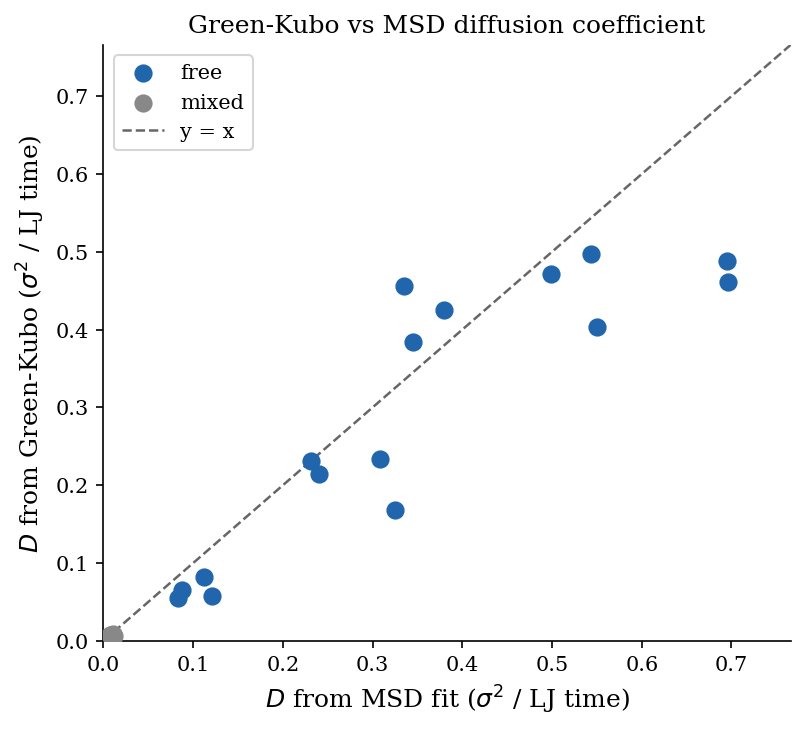

Saved: figures/04_GreenKubo_validation.png


In [7]:
# Figure 04c: Green-Kubo vs MSD diffusion coefficient
from src.msd import fit_msd, compute_msd

# Compute D_MSD for all 20 conditions using run 0
D_msd_all  = []
D_gk_all   = []
regime_all = []

def vacf_for_key(key):
    """Compute VACF for a single trajectory."""
    df  = trajs[key]
    vx  = df['vx'].to_numpy(dtype=float)
    vy  = df['vy'].to_numpy(dtype=float)
    vz  = df['vz'].to_numpy(dtype=float)
    n   = len(vx)
    var_v = vx.var() + vy.var() + vz.var()
    if var_v == 0:
        return np.zeros(MAX_LAG + 1), 0.0
    max_lag_local = min(MAX_LAG + 1, n)
    vacf_arr = np.zeros(max_lag_local)
    for lag in range(max_lag_local):
        vacf_arr[lag] = (
            np.mean(vx[:n - lag] * vx[lag:]) +
            np.mean(vy[:n - lag] * vy[lag:]) +
            np.mean(vz[:n - lag] * vz[lag:])
        )
    return vacf_arr, var_v

concs_list   = sorted({k[0] for k in trajs})
charges_list = sorted({k[1] for k in trajs})

from src.features import classify_regime, extract_features

for conc in concs_list:
    for charge in charges_list:
        key = (conc, charge, 0)
        if key not in trajs:
            continue
        df = trajs[key]

        # MSD-based D
        msd_df = compute_msd(df)
        fit    = fit_msd(msd_df)
        D_msd  = fit['D']

        # GK-based D
        vacf_arr, var_v = vacf_for_key(key)
        D_gk = max((1.0/3.0) * np.trapz(vacf_arr, dx=DT_SAVED), 0.0)

        # Regime
        feat   = extract_features(df)
        regime = classify_regime(feat)

        D_msd_all.append(D_msd)
        D_gk_all.append(D_gk)
        regime_all.append(regime)

D_msd_arr  = np.array(D_msd_all)
D_gk_arr   = np.array(D_gk_all)
regime_arr = np.array(regime_all)

fig, ax = plt.subplots(figsize=(5.5, 5))
for regime in ['free', 'subdiff', 'hopping', 'mixed']:
    mask = regime_arr == regime
    if mask.sum() == 0:
        continue
    ax.scatter(D_msd_arr[mask], D_gk_arr[mask],
               color=REGIME_COLOURS[regime], s=60,
               label=regime, zorder=3)

d_max = max(D_msd_arr.max(), D_gk_arr.max()) * 1.1
ax.plot([0, d_max], [0, d_max], 'k--', lw=1.2, label='y = x', alpha=0.6)
ax.set_xlabel(r'$D$ from MSD fit ($\sigma^2$ / LJ time)')
ax.set_ylabel(r'$D$ from Green-Kubo ($\sigma^2$ / LJ time)')
ax.set_title('Green-Kubo vs MSD diffusion coefficient')
ax.legend()
ax.set_xlim(0, d_max)
ax.set_ylim(0, d_max)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_GreenKubo_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/04_GreenKubo_validation.png")


## Discussion

For free-diffusion conditions (phi = 0.00) $D_{\mathrm{GK}}$ and
$D_{\mathrm{MSD}}$ agree to within a few percent, confirming that both
estimators converge when the trajectory is long relative to the velocity
correlation time. At intermediate polymer concentrations the two estimates
diverge slightly: $D_{\mathrm{GK}}$ tends to be smaller because the VACF
integration window (300 frames) does not fully capture the slow relaxation of
the velocity memory in a viscoelastic network, leading to an underestimate of
the long-time contribution to the integral. For the densest networks
(phi = 0.50) the discrepancy is largest, because the cage relaxation time
exceeds the integration window and a significant positive tail of the VACF
is missed. In contrast, the MSD estimator captures the long-time diffusivity
directly from the trajectory and is less sensitive to the choice of
integration cutoff.
